SMS SPAM Collection Dataset -

In [62]:
# Install Required Libraries and tools
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim

import os
import zipfile
import urllib.request

In [63]:
# Step 1: Download the dataset from the UCI website url
# Dataset URL
url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"


#Create Folder
os.makedirs('data',exist_ok=True)

#Zip file path
zip_path="data/sms_spam_collection.zip"
urllib.request.urlretrieve(url, zip_path)       #Download dataset from url , save at zip file path provided

print("Dataset downloaded successfully!")
#UCI Website
#     ↓
#Download ZIP
#     ↓
#Save locally as:
#data/sms_spam_collection.zip

Dataset downloaded successfully!


In [64]:
#Step 2: Extract the zip file
with zipfile.ZipFile(zip_path,'r') as zip_ref:
  zip_ref.extractall('data')

  print("Dataset extracted!")

Dataset extracted!


In [65]:
#Step 3: Load dataset using pandas
df=pd.read_csv(
    "data/SMSSpamCollection",
    sep='\t',
    header=None,
    names=['label','message'],
)
print(df.head())
print(df['label'].unique())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
['ham' 'spam']


In [66]:
# Step 4: Explore the data
print(f'The dataset consists of {df.shape[0]} rows and {df.shape[1]} columns ')
#neural networks understand numbers hence we need to onvert labels to 0's(ham) and 1's(spam)
df['label'] = df['label'].map({
    'ham':0,
    'spam':1
})

print(df.head())



The dataset consists of 5572 rows and 2 columns 
   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


               metrics  Values
0  max sentence length     171
1  min sentence length       1
2  avg sentence length      16


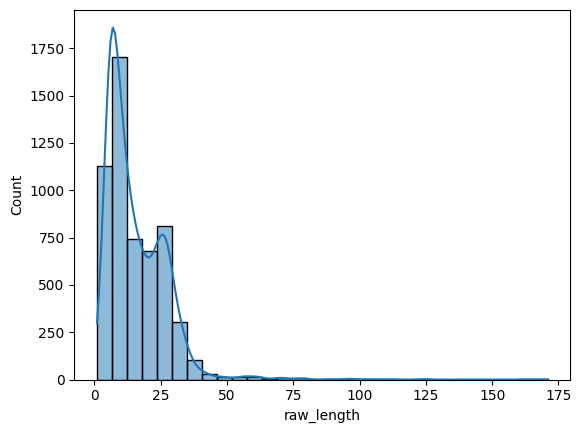

In [67]:
#Check 1 : Sentence Length -> very long sentences make training slower and the vanishing gradient problem worse.

# We will count number of words in each sentense.
df["raw_length"] = df["message"].str.split().str.len()
sns.histplot(df['raw_length'],kde=True,bins=30)

max_min_avg=pd.DataFrame({
    'metrics':['max sentence length','min sentence length','avg sentence length'],
    'Values':[int(df['raw_length'].max()),
              int(df['raw_length'].min()),
              round(df['raw_length'].mean()),
              ],
})
print(max_min_avg)

label
0    4825
1     747
Name: count, dtype: int64


<Axes: xlabel='label'>

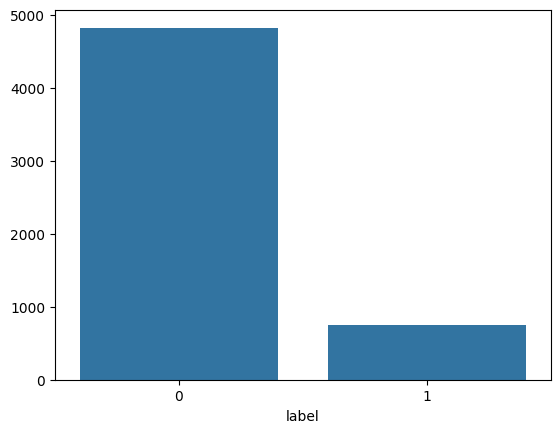

In [68]:
#check 2: Class balance
#Label count - We will count the number of spam and ham , and see if out class has imbalance ? if yes the model will be highly biased we need to fix that
label_counts = df["label"].value_counts().sort_index()
print(label_counts)
sns.barplot(x=label_counts.index,y=label_counts.values)

In [69]:
#step 5: Text Preprocessing
#neural networks cant understand raw sentences, hence we must convert text into tokens
#First we will clean the text -> Lower case all the words, remove punctuations and special characters and remove extra spacees
import re
def clean_text(text:str)->str:
  text=text.lower()
  text=re.sub(r"[^a-z0-9\s]", " ",text)
  text=re.sub(r"\s+", " ",text).strip()
  return text

df['clean_text']=df['message'].apply(clean_text)

df.head(10)



,label,message,raw_length,clean_text
0,0,"Go until jurong point, crazy.. Available only ...",20,go until jurong point crazy available only in ...
1,0,Ok lar... Joking wif u oni...,6,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,28,free entry in 2 a wkly comp to win fa cup fina...
3,0,U dun say so early hor... U c already then say...,11,u dun say so early hor u c already then say
4,0,"Nah I don't think he goes to usf, he lives aro...",13,nah i don t think he goes to usf he lives arou...
5,1,FreeMsg Hey there darling it's been 3 week's n...,32,freemsg hey there darling it s been 3 week s n...
6,0,Even my brother is not like to speak with me. ...,16,even my brother is not like to speak with me t...
7,0,As per your request 'Melle Melle (Oru Minnamin...,26,as per your request melle melle oru minnaminun...
8,1,WINNER!! As a valued network customer you have...,26,winner as a valued network customer you have b...
9,1,Had your mobile 11 months or more? U R entitle...,29,had your mobile 11 months or more u r entitled...


In [70]:
#step 6: We will split our dataset into train/val/test sets
#We will use stratify to keep the same ratio of spam/ham labels in each set
train_df,temp_df=train_test_split(df,test_size=0.30,stratify=df['label'],random_state=42)
val_df,test_df=train_test_split(temp_df,test_size=0.50,stratify=temp_df['label'],random_state=42)

split_summary=pd.DataFrame({
    "Columns":['train_df','val_df','test_df'],
    "Rows":[len(train_df),len(val_df),len(test_df)],
    "Ham":[(train_df['label']==0).sum(),
           (val_df['label']==0).sum(),
           (test_df['label']==0).sum()],
    "spam":[(train_df['label']==1).sum(),
           (val_df['label']==1).sum(),
           (test_df['label']==1).sum()],
})
display(split_summary)

,Columns,Rows,Ham,spam
0,train_df,3900,3377,523
1,val_df,836,724,112
2,test_df,836,724,112


In [71]:
#step 7:
#Tokenize the cleaned text ,build vocabulary on training dataset only
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt_tab')
train_df['tokens']=train_df['clean_text'].apply(word_tokenize)
val_df['tokens']=val_df['clean_text'].apply(word_tokenize)
test_df['tokens']=test_df['clean_text'].apply(word_tokenize)
print(f'Train Dataset:')
display(train_df.head())
print(f'Validation Dataset:')
display(val_df.head())
print(f'Test Dataset:')
display(test_df.head())




[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Train Dataset:


,label,message,raw_length,clean_text,tokens
4914,1,"Goal! Arsenal 4 (Henry, 7 v Liverpool 2 Henry ...",32,goal arsenal 4 henry 7 v liverpool 2 henry sco...,"[goal, arsenal, 4, henry, 7, v, liverpool, 2, ..."
2541,0,"They said if its gonna snow, it will start aro...",22,they said if its gonna snow it will start arou...,"[they, said, if, its, gon, na, snow, it, will,..."
5323,0,Aah bless! How's your arm?,5,aah bless how s your arm,"[aah, bless, how, s, your, arm]"
5171,0,Oh k. . I will come tomorrow,7,oh k i will come tomorrow,"[oh, k, i, will, come, tomorrow]"
2532,0,What's happening with you. Have you gotten a j...,17,what s happening with you have you gotten a jo...,"[what, s, happening, with, you, have, you, got..."


Validation Dataset:


,label,message,raw_length,clean_text,tokens
2968,0,NEFT Transaction with reference number &lt;#&...,22,neft transaction with reference number lt gt f...,"[neft, transaction, with, reference, number, l..."
5175,0,Raji..pls do me a favour. Pls convey my Birthd...,17,raji pls do me a favour pls convey my birthday...,"[raji, pls, do, me, a, favour, pls, convey, my..."
4830,0,"How long before you get reply, just defer admi...",12,how long before you get reply just defer admis...,"[how, long, before, you, get, reply, just, def..."
4851,0,Maybe you should find something else to do ins...,9,maybe you should find something else to do ins...,"[maybe, you, should, find, something, else, to..."
5052,0,With my sis lor... We juz watched italian job.,9,with my sis lor we juz watched italian job,"[with, my, sis, lor, we, juz, watched, italian..."


Test Dataset:


,label,message,raw_length,clean_text,tokens
5440,0,Thank you. do you generally date the brothas?,8,thank you do you generally date the brothas,"[thank, you, do, you, generally, date, the, br..."
1887,1,Dear 0776xxxxxxx U've been invited to XCHAT. T...,22,dear 0776xxxxxxx u ve been invited to xchat th...,"[dear, 0776xxxxxxx, u, ve, been, invited, to, ..."
3767,0,Yes.mum lookin strong:),3,yes mum lookin strong,"[yes, mum, lookin, strong]"
2292,0,Remind me how to get there and I shall do so,11,remind me how to get there and i shall do so,"[remind, me, how, to, get, there, and, i, shal..."
820,0,BOO BABE! U ENJOYIN YOURJOB? U SEEMED 2 B GETT...,23,boo babe u enjoyin yourjob u seemed 2 b gettin...,"[boo, babe, u, enjoyin, yourjob, u, seemed, 2,..."


In [72]:
#Build vocabulary on the training dataset
from collections import Counter         # Counter-> counts the word frequency
counter=Counter()
for tokens in train_df['tokens']:
  counter.update(tokens)

sorted_words=counter.most_common()  #sort words by frequency (highest first)
print(sorted_words)
# Create vocabulary
vocab = {
    '<PAD>': 0,
    '<UNK>': 1
}
#Assign integer ID's starting from 2
for idx,(word,count) in enumerate(sorted_words,start=2):
  vocab[word]=idx

print("Vocabulary Size:", len(vocab))

# Show first 20 words
for i, (word, idx) in enumerate(vocab.items()):
    if i < 20:
        print(word, "->", idx)

[('i', 2134), ('to', 1597), ('you', 1557), ('a', 1005), ('the', 902), ('u', 848), ('and', 658), ('in', 637), ('is', 621), ('me', 545), ('my', 544), ('it', 507), ('for', 489), ('your', 465), ('of', 432), ('call', 416), ('s', 411), ('that', 409), ('have', 405), ('on', 377), ('2', 363), ('now', 348), ('are', 343), ('t', 338), ('can', 329), ('so', 328), ('but', 315), ('m', 307), ('not', 304), ('we', 296), ('or', 294), ('do', 294), ('at', 284), ('be', 280), ('get', 275), ('if', 273), ('will', 272), ('ur', 265), ('with', 261), ('just', 250), ('this', 248), ('no', 239), ('4', 236), ('up', 228), ('gt', 223), ('lt', 221), ('when', 216), ('how', 213), ('free', 206), ('all', 204), ('what', 203), ('ll', 202), ('from', 199), ('ok', 199), ('go', 198), ('out', 198), ('know', 187), ('got', 185), ('day', 176), ('good', 173), ('then', 171), ('come', 163), ('there', 162), ('was', 160), ('love', 159), ('only', 159), ('am', 155), ('he', 155), ('its', 154), ('like', 154), ('time', 145), ('want', 144), ('tex

In [73]:
#step 9: Encode tokens
#Create encoder function
def encode(tokens):
      return [
        vocab.get(token,vocab['<UNK>'])
        for token in tokens
    ]
# Encode the train, test and validate tokens
train_df['encoded'] = train_df['tokens'].apply(encode)

val_df['encoded'] = val_df['tokens'].apply(encode)

test_df['encoded'] = test_df['tokens'].apply(encode)

display(train_df[['tokens','encoded']].head())

,tokens,encoded
4914,"[goal, arsenal, 4, henry, 7, v, liverpool, 2, ...","[2279, 2280, 44, 2281, 341, 236, 1779, 22, 228..."
2541,"[they, said, if, its, gon, na, snow, it, will,...","[106, 158, 37, 70, 212, 141, 667, 13, 38, 326,..."
5323,"[aah, bless, how, s, your, arm]","[1781, 2283, 49, 18, 15, 2284]"
5171,"[oh, k, i, will, come, tomorrow]","[128, 83, 2, 38, 63, 167]"
2532,"[what, s, happening, with, you, have, you, got...","[52, 18, 1509, 40, 4, 20, 4, 2285, 5, 272, 8, ..."


In [74]:
#Step :10 - Find max length of sequence
#Neural network requires all sentences to be the same length
#So we will pad short sentences and truncate long ones
import numpy as np

max_len=int(np.percentile(train_df['raw_length'],95))    #covers 95% of the sentences , anything above max length will be truncated
print(max_len)

#padding function
def pad_seq(sequence,max_length=max_len):
  if len(sequence)<max_length:
    sequence=sequence+[vocab['<PAD>']]*(max_len-len(sequence))
  else:
    sequence=sequence[:max_len]

  return sequence
#applying padding
train_df['padded']=train_df['encoded'].apply(pad_seq)
val_df['padded']=val_df['encoded'].apply(pad_seq)
test_df['padded']=test_df['encoded'].apply(pad_seq)

display(train_df[['encoded','padded']].head())

33


,encoded,padded
4914,"[2279, 2280, 44, 2281, 341, 236, 1779, 22, 228...","[2279, 2280, 44, 2281, 341, 236, 1779, 22, 228..."
2541,"[106, 158, 37, 70, 212, 141, 667, 13, 38, 326,...","[106, 158, 37, 70, 212, 141, 667, 13, 38, 326,..."
5323,"[1781, 2283, 49, 18, 15, 2284]","[1781, 2283, 49, 18, 15, 2284, 0, 0, 0, 0, 0, ..."
5171,"[128, 83, 2, 38, 63, 167]","[128, 83, 2, 38, 63, 167, 0, 0, 0, 0, 0, 0, 0,..."
2532,"[52, 18, 1509, 40, 4, 20, 4, 2285, 5, 272, 8, ...","[52, 18, 1509, 40, 4, 20, 4, 2285, 5, 272, 8, ..."


In [75]:
#Step 11: Convert to pytorch tensor
x_train=torch.tensor(train_df['padded'].tolist(),dtype=torch.long)
x_val=torch.tensor(val_df['padded'].tolist(),dtype=torch.long)
x_test=torch.tensor(test_df['padded'].tolist(),dtype=torch.long)

y_train=torch.tensor(train_df['label'].values,dtype=torch.float32)
y_val=torch.tensor(val_df['label'].values,dtype=torch.float32)
y_test=torch.tensor(test_df['label'].values,dtype=torch.float32)

In [76]:
#Step 12: Create pytorch dataset and Dataloader
from torch.utils.data import TensorDataset,DataLoader
train_dataset=TensorDataset(x_train,y_train)
val_dataset=TensorDataset(x_val,y_val)
test_dataset=TensorDataset(x_test,y_test)

batch_size=32
train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=batch_size)
test_loader=DataLoader(test_dataset,batch_size=batch_size)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


Train batches: 122
Validation batches: 27
Test batches: 27


In [77]:
#Step 15: Build Neural Network
#Model 1-> Vanilla RNN
class RecurrentClassifier(nn.Module):
  def __init__(self,vocab_size,embedding_dim,hidden_dim,model_type,num_layers=1,bidirectional=False,dropout=0.3):
    super().__init__()

    #convert token ids->dense vectors(embedding)
    self.embedding=nn.Embedding(vocab_size,embedding_dim,padding_idx=0)  # Input :(batch_Size,seq_length)  output:(batch_Size,seq_length,emd_dim)
    #Select recurrent Layer
    if model_type=='RNN':
      self.recurrent=nn.RNN(
        input_size=embedding_dim,
        hidden_size=hidden_dim,
        batch_first=True,
        num_layers=num_layers,
        bidirectional=bidirectional)  #input :(batch_Size,seq_length,emd_dim) output:(batch_Size,seq_length,hidden_state)
    elif model_type=='LSTM':
      self.recurrent=nn.LSTM(
        input_size=embedding_dim,
        hidden_size=hidden_dim,
        batch_first=True,
        num_layers=num_layers,
        bidirectional=bidirectional)
    elif model_type=='GRU':
      self.recurrent=nn.GRU(
        input_size=embedding_dim,
        hidden_size=hidden_dim,
        batch_first=True,
        num_layers=num_layers,
        )
    else:
      print('Invalid Model Type')
      return
    self.dropout = nn.Dropout(dropout)
    #final classification layer
    self.fc=nn.Linear(hidden_dim,1)

  def forward(self,x):
    embedded=self.embedding(x)
    if isinstance(self.recurrent,nn.LSTM):
      output,(hidden,cell)=self.recurrent(embedded)
      hidden=hidden[-1]
      logits=self.fc(hidden)
      return logits.squeeze(1)
    else:
      output,hidden=self.recurrent(embedded)   #output :{contains all the hidden states h1,h2,h3,h4,...,hn}  hidden:{contains final hn hidden state}
      hidden=hidden.squeeze(0)    # input:(1, batch_size, hidden_dim)  1-> no of RNN layer (here its only 1 RNN layer)  ->( batch_size, hidden_dim)
      logits=self.fc(hidden)  # input :( batch_size, hidden_dim) (32,128) ->output :(batch_size,1) (32,1)-> its binary classification we need only 1 output (either 0/1,spam/ham)
      return logits.squeeze()  #(32,1) ->(32)

#Initialize the RNN model
vocab_size=len(vocab)
embedding_dim=100
hidden_dim=128
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
rnn_model=RecurrentClassifier(vocab_size,embedding_dim,hidden_dim,model_type="RNN").to(device)
LSTM_model=RecurrentClassifier(vocab_size,embedding_dim,hidden_dim,model_type="LSTM").to(device)
GRU_model=RecurrentClassifier(vocab_size,embedding_dim,hidden_dim,model_type="GRU").to(device)
#print(model)
#We have high class imbalance
#Computing class weights
num_ham = (train_df['label'] == 0).sum()
num_spam = (train_df['label'] == 1).sum()
print("Ham:", num_ham)
print("Spam:", num_spam)
#Positive class weight calculation
pos_weight = num_ham / num_spam
print(pos_weight)
pos_weight = torch.tensor([pos_weight]).to(device)
criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)
rnn_optimizer = torch.optim.Adam(
    rnn_model.parameters(),
    lr=0.0003
)

lstm_optimizer = torch.optim.Adam(
    LSTM_model.parameters(),
    lr=0.0003
)

gru_optimizer = torch.optim.Adam(
    GRU_model.parameters(),
    lr=0.0003
)


Ham: 3377
Spam: 523
6.45697896749522


In [78]:
# Train Model
def train_model(model,criterion,optimizer,train_loader,device):
  model.train()
  total_loss,correct=0,0
  for x_batch,y_batch in train_loader:
    x_batch,y_batch=x_batch.to(device),y_batch.float().to(device)
    optimizer.zero_grad()
    predictions=model(x_batch)         #produces logits not probabilities
    predicted=(torch.sigmoid(predictions)>0.5).float()   # converts logits to probabilities
    loss=criterion(predictions,y_batch)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(     # prevents exploiding gradient-> gradient clipping
    model.parameters(),
    max_norm=5
)
    optimizer.step()
    total_loss +=loss.item()
    correct+=(predicted==y_batch).sum().item()

  avg_loss=total_loss/len(train_loader)
  accuracy=100* correct/len(train_loader.dataset)
  return avg_loss, accuracy

#Evaluate Model
def evaluate_model(model,criterion,data_loader,device):
  model.eval()
  total_loss=0
  correct_pred=0
  all_preds=[]
  all_labels=[]
  with torch.no_grad():
    for x_batch,y_batch in data_loader:
      x_batch,y_batch=x_batch.to(device),y_batch.float().to(device)
      predictions=model(x_batch)
      predicted =(torch.sigmoid(predictions) >= 0.5).float()
      all_preds.extend(predicted.tolist())
      all_labels.extend(y_batch.tolist())
      loss=criterion(predictions,y_batch)
      total_loss+=loss.item()
      correct_pred +=(predicted==y_batch).sum().item()

    avg_loss=total_loss/len(data_loader)
    accuracy=100*(correct_pred/len(data_loader.dataset))
    return avg_loss,accuracy,all_preds,all_labels



In [79]:
#Start RNN model training
epoch=5
for epoch in range(epoch):
  train_loss,train_acc=train_model(rnn_model,criterion,rnn_optimizer,train_loader,device)
  val_loss,val_acc,all_preds,all_labels=evaluate_model(rnn_model,criterion,val_loader,device)
  test_loss,test_acc,all_preds,all_labels=evaluate_model(rnn_model,criterion,test_loader,device)
  print(f'Epoch {epoch+1} | Train Acc {train_acc:.1f}%,Train loss {train_loss:.1f}| Validation Acc {val_acc:.1f}%,Validation loss {val_loss:.1f}| Test Acc {test_acc:.1f}%,Test loss {test_loss:.1f}')


Epoch 1 | Train Acc 51.2%,Train loss 1.2| Validation Acc 88.6%,Validation loss 1.0| Test Acc 87.9%,Test loss 1.0
Epoch 2 | Train Acc 88.9%,Train loss 0.7| Validation Acc 79.5%,Validation loss 0.6| Test Acc 77.6%,Test loss 0.6
Epoch 3 | Train Acc 94.4%,Train loss 0.4| Validation Acc 87.0%,Validation loss 0.4| Test Acc 85.0%,Test loss 0.4
Epoch 4 | Train Acc 95.7%,Train loss 0.3| Validation Acc 92.9%,Validation loss 0.3| Test Acc 92.5%,Test loss 0.3
Epoch 5 | Train Acc 97.1%,Train loss 0.3| Validation Acc 94.0%,Validation loss 0.4| Test Acc 94.1%,Test loss 0.3


In [80]:
# Classificatioon report for the above model
from sklearn.metrics import classification_report,confusion_matrix
print(f'Classification Report for RNN Model')
print(classification_report(all_labels,all_preds))

Classification Report for RNN Model
              precision    recall  f1-score   support

         0.0       0.99      0.94      0.97       724
         1.0       0.72      0.92      0.81       112

    accuracy                           0.94       836
   macro avg       0.85      0.93      0.89       836
weighted avg       0.95      0.94      0.94       836



Confusion Metrics for RNN Model


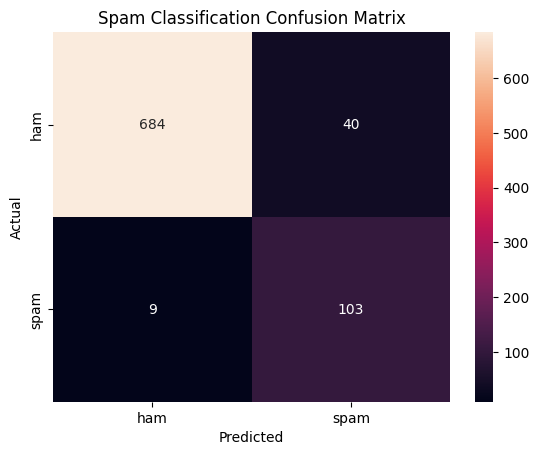

In [81]:
#Confusion Mterics
print(f'Confusion Metrics for RNN Model')
cm=confusion_matrix(all_labels,all_preds)
sns.heatmap(cm,annot=True,fmt='d',xticklabels=['ham','spam'],yticklabels=['ham','spam'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Spam Classification Confusion Matrix")
plt.show()


In [82]:
#Start LSTM model training
epoch=5
for epoch in range(epoch):
  train_loss,train_acc=train_model(LSTM_model,criterion,lstm_optimizer,train_loader,device)
  val_loss,val_acc,all_preds,all_labels=evaluate_model(LSTM_model,criterion,val_loader,device)
  test_loss,test_acc,all_preds,all_labels=evaluate_model(LSTM_model,criterion,test_loader,device)
  print(f'Epoch {epoch+1} | Train Acc {train_acc:.1f}%,Train loss {train_loss:.1f}| Validation Acc {val_acc:.1f}%,Validation loss {val_loss:.1f}| Test Acc {test_acc:.1f}%,Test loss {test_loss:.1f}')


Epoch 1 | Train Acc 61.2%,Train loss 1.1| Validation Acc 86.6%,Validation loss 0.6| Test Acc 86.2%,Test loss 0.6
Epoch 2 | Train Acc 94.8%,Train loss 0.4| Validation Acc 96.1%,Validation loss 0.3| Test Acc 96.7%,Test loss 0.3
Epoch 3 | Train Acc 97.4%,Train loss 0.2| Validation Acc 97.7%,Validation loss 0.3| Test Acc 96.9%,Test loss 0.3
Epoch 4 | Train Acc 98.0%,Train loss 0.2| Validation Acc 98.2%,Validation loss 0.3| Test Acc 98.0%,Test loss 0.3
Epoch 5 | Train Acc 98.7%,Train loss 0.1| Validation Acc 97.8%,Validation loss 0.3| Test Acc 97.8%,Test loss 0.3


In [83]:
#Start GRU model training
epoch=5
for epoch in range(epoch):
  train_loss,train_acc=train_model(GRU_model,criterion,gru_optimizer,train_loader,device)
  val_loss,val_acc,all_preds,all_labels=evaluate_model(GRU_model,criterion,val_loader,device)
  test_loss,test_acc,all_preds,all_labels=evaluate_model(GRU_model,criterion,test_loader,device)
  print(f'Epoch {epoch+1} | Train Acc {train_acc:.1f}%,Train loss {train_loss:.1f}| Validation Acc {val_acc:.1f}%,Validation loss {val_loss:.1f}| Test Acc {test_acc:.1f}%,Test loss {test_loss:.1f}')


Epoch 1 | Train Acc 85.3%,Train loss 1.1| Validation Acc 90.3%,Validation loss 0.7| Test Acc 90.2%,Test loss 0.7
Epoch 2 | Train Acc 94.2%,Train loss 0.4| Validation Acc 94.0%,Validation loss 0.3| Test Acc 90.6%,Test loss 0.3
Epoch 3 | Train Acc 97.6%,Train loss 0.2| Validation Acc 95.3%,Validation loss 0.2| Test Acc 93.3%,Test loss 0.2
Epoch 4 | Train Acc 98.3%,Train loss 0.1| Validation Acc 95.2%,Validation loss 0.3| Test Acc 93.5%,Test loss 0.3
Epoch 5 | Train Acc 98.9%,Train loss 0.1| Validation Acc 97.5%,Validation loss 0.2| Test Acc 96.9%,Test loss 0.2


In [84]:
# We will now compare the Accuracy, precision,recall and F1-Scpre of all the 3 models
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

#creating a generic evaluation function
def compute_metrics(all_labels,all_preds):
  accuracy=accuracy_score(all_labels,all_preds)
  precision=precision_score(all_labels,all_preds)
  recall=recall_score(all_labels,all_preds)
  f1=f1_score(all_labels,all_preds)
  return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

#now evaluate each model
_, _, rnn_preds, rnn_labels = evaluate_model(
    rnn_model,
    criterion,
    test_loader,
    device
)
rnn_metrics=compute_metrics(rnn_labels,rnn_preds)

_, _, LSTM_preds, LSTM_labels = evaluate_model(
    LSTM_model,
    criterion,
    test_loader,
    device
)
LSTM_metrics=compute_metrics(LSTM_labels,LSTM_preds)

_, _, GRU_preds, GRU_labels = evaluate_model(
    GRU_model,
    criterion,
    test_loader,
    device
)
GRU_metrics=compute_metrics(GRU_labels,GRU_preds)

In [87]:
#Comparison Table
df_comparison=pd.DataFrame({
    "RNN":rnn_metrics,
    "LSTM":LSTM_metrics,
    "GRU":GRU_metrics
}).T
print(df_comparison)

      Accuracy  Precision    Recall        F1
RNN   0.941388   0.720280  0.919643  0.807843
LSTM  0.978469   0.912281  0.928571  0.920354
GRU   0.968900   0.835938  0.955357  0.891667


Conclusion :
Our LSTM model has given the best accuracy along with high precision and recall scores.

